# Chemical space

This tutorial is about the one design decision that most distinguishes matverse
from a DataFrame with a `structure` column: **`X` is the composition matrix and
`var` is the periodic table**.

It picks up where [Screening, end to end](screening.ipynb) left off — same
Al–Ni–Cu library, same `passes` column — and asks the question that follows
every screen: *what chemistry is on the shortlist?*

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

matverse 0.1.12 — 121 functions


## Loading a dataset

Rebuilding the screening object in one cell: three elemental fcc metals at their
published lattice parameters, four hypothetical intermetallics, relaxed and
screened with `emt`.

In [2]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    return Structure(Lattice.cubic(a), [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


elemental = mv.datasets.metals(["Al", "Cu", "Ni"])
md = mv.data.from_structures(mv.structures(elemental) + [
    l12("Al", "Cu", 3.90), l12("Cu", "Al", 3.70), l12("Al", "Ni", 3.78),
    Structure(Lattice.cubic(2.89), ["Al", "Ni"], [[0, 0, 0], [.5, .5, .5]]),
])

mv.pp.describe(md)
mv.calc.relax(md, level="emt", fmax=0.05)
mv.thermo.hull(md, level="emt", source="relaxed_emt")
mv.screen.filter(md, e_above_hull_emt__lt=0.12, density__lt=8.0)

md.obs[["formula", "e_above_hull_emt", "density", "passes"]].round(3)

/scratch/users/steorra/analysis/omicverse_dev/matverse/matverse/_registry.py:346: UserWarning: hull for level 'emt' was built over this dataset's own compositions only, so e_above_hull is relative to these candidates and not to the known phase diagram. Pass references= to make it absolute; see uns['phase_diagram']['closed_system'].
  return func(*args, **kwargs)


,formula,e_above_hull_emt,density,passes
0,Al,0.000,2.699,True
1,Cu,0.000,8.935,False
2,Ni,0.000,8.908,False
3,Al3Cu,0.082,4.045,True
4,AlCu3,0.113,7.134,True
5,Al3Ni,0.186,4.293,False
6,AlNi,0.435,5.894,False


## Why elements are the right axis

A composition matrix is materials × elements — sparse, non-negative, and almost
entirely zero, because nearly every material draws on five or fewer of 118
columns. That is structurally a cells × genes matrix.

In [3]:
pd.DataFrame(md.X.toarray(), index=md.obs["formula"], columns=md.var_names)

element,Al,Ni,Cu
formula,,,
Al,1.0,0.0,0.0
Cu,0.0,0.0,1.0
Ni,0.0,1.0,0.0
Al3Cu,3.0,0.0,1.0
AlCu3,1.0,0.0,3.0
Al3Ni,3.0,1.0,0.0
AlNi,1.0,1.0,0.0


Counts come from the **reduced** formula, so a supercell and its primitive cell
occupy the same point in chemical space. Cell size belongs in `obs['nsites']`,
not in the chemistry.

`var` carries the periodic table, which is what makes element-level results
interpretable without a lookup somewhere else:

In [4]:
md.var[["Z", "electronegativity", "period", "is_transition_metal"]]

,Z,electronegativity,period,is_transition_metal
element,,,,
Al,13.0,1.61,3.0,False
Ni,28.0,1.91,4.0,True
Cu,29.0,1.90,4.0,True


```{note}
Economic properties — price, supply risk, criticality — are deliberately **not**
shipped. They are jurisdiction- and date-dependent and no authoritative open
table exists, so inventing numbers would make `mv.screen.filter(md,
supply_risk__lt=0.3)` return confident nonsense. Attach your own instead.
```

In [5]:
mv.elements.annotate(md, pd.DataFrame(
    {"price_usd_kg": [2.4, 18.0, 9.5]}, index=["Al", "Ni", "Cu"]))

md.var[["price_usd_kg"]]

,price_usd_kg
element,
Al,2.4
Ni,18.0
Cu,9.5


## The dividend inside the library

Because `X` holds the composition and `var` holds the element properties, the
classic composition descriptor — the weighted mean, spread and range of element
properties across a formula — is a matrix product of two things the object is
already carrying.

In [6]:
mv.feat.element_stats(md)
md.obsm["X_element_stats"].shape

(7, 130)

Check one by hand. For Al₃Cu the weighted mean electronegativity should be
exactly `0.75 × 1.61 + 0.25 × 1.90`:

In [7]:
names = list(md.uns["features"]["X_element_stats"]["names"])
j = names.index("electronegativity_mean")
row = list(md.obs["formula"]).index("Al3Cu")

md.obsm["X_element_stats"][row, j], 0.75 * 1.61 + 0.25 * 1.90

(np.float64(1.6825), 1.6825)

`min`, `max` and `range` are taken over the elements that are *present at all*,
so "the most electronegative element in this compound" is the quantity it sounds
like rather than an amount-weighted blend.

Composition descriptors cannot tell two polymorphs apart, because polymorphs have
the same composition. When that matters, reach for a structure descriptor:

```python
mv.feat.soap(md)          # needs matverse[descriptors]
```

## Mapping the space

In [8]:
mv.pp.normalize_composition(md)     # -> layers['fraction']
mv.tl.pca(md, n_comps=2)
mv.tl.neighbors(md, n_neighbors=3)
mv.tl.cluster(md, method="kmeans", n_clusters=2)

md.obs[["formula", "cluster"]]

,formula,cluster
0,Al,0
1,Cu,1
2,Ni,0
3,Al3Cu,0
4,AlCu3,1
5,Al3Ni,0
6,AlNi,0


`normalize_composition` writes atomic fractions to a **layer** rather than
replacing `X`, because a hull needs the counts and a chemical-space map needs
the fractions. `mv.tl.pca` defaults to the fraction layer when it exists: raw
counts scale with the size of the formula unit, so `Fe2O3` and `Fe4O6` would
otherwise sit at different points despite being the same chemistry.

PCA here is an exact SVD. The element axis is at most 118 columns wide, so there
is nothing to approximate and no randomised solver to configure.

Text(0.5, 1.0, 'chemical space, coloured by cluster')

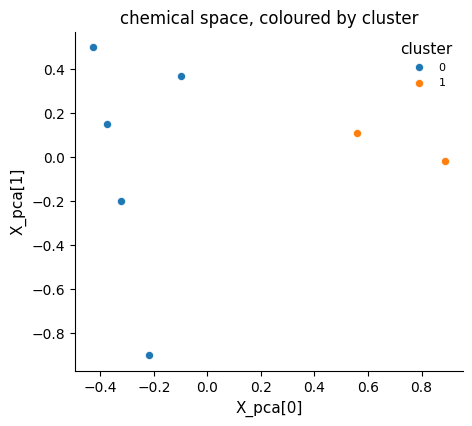

In [9]:
ax = mv.pl.embedding(md, color="cluster")
ax.set_title("chemical space, coloured by cluster")

## The question that follows every screen

You have a shortlist. What chemistry is on it?

In [10]:
mv.tl.rank_elements_groups(md, "passes")

md.uns["rank_elements_groups"]["True"]

,element,n_in_group,n_rest,frac_in_group,frac_rest,odds_ratio,pval,qval,log2_odds,group
0,Ni,0,3,0.000000,0.75,0.0,0.142857,0.428571,NaN,True
1,Al,3,2,1.000000,0.50,inf,0.428571,0.485714,inf,True
2,Cu,2,1,0.666667,0.25,6.0,0.485714,0.485714,2.584963,True


This is `rank_genes_groups` with the nouns changed, and it is the operation that
justifies the whole design choice. Answering the same question from a DataFrame
of averaged Magpie descriptors means writing the contingency table and the test
by hand, every time, for every screen.

Two routes, because "which elements" has two meanings — how *often* an element
appears in the group, and how *much* of it there is.

In [11]:
mv.tl.rank_elements_groups(md, "passes", method="fraction")   # Wilcoxon

md.uns["rank_elements_groups"]["True"][
    ["element", "mean_frac_in_group", "mean_frac_rest", "diff", "pval", "qval"]]

,element,mean_frac_in_group,mean_frac_rest,diff,pval,qval
0,Ni,0.000000,0.4375,-0.437500,0.111612,0.323887
1,Al,0.666667,0.3125,0.354167,0.215925,0.323887
2,Cu,0.333333,0.2500,0.083333,0.595883,0.595883


Both report an uncorrected p-value and a Benjamini–Hochberg q-value. With seven
materials nothing here is significant, and the table says so — which is the point
of reporting both.

The natural display is the periodic table, in the way a dot plot is the natural
display for differential expression.

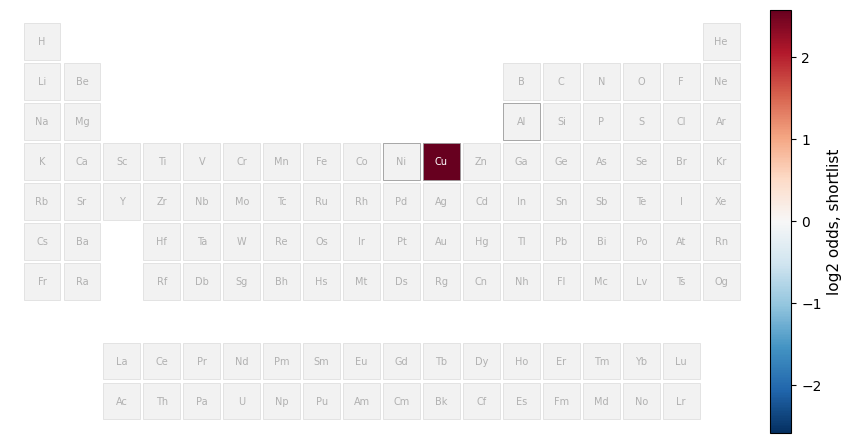

In [12]:
mv.tl.rank_elements_groups(md, "passes")
frame = md.uns["rank_elements_groups"]["True"]
scores = frame.set_index("element")["log2_odds"].reindex(md.var_names)

ax = mv.pl.periodic_table(md, values=scores.to_numpy(),
                          label="log2 odds, shortlist", center=0.0)

Aluminium comes out grey rather than dark. Its odds ratio is infinite — it is in
every shortlisted material and the log is undefined — and `mv.pl.periodic_table`
leaves non-finite values uncoloured instead of clipping them to the top of the
scale, so a cell that is grey means "no number", never "zero enrichment".

With seven materials that will happen often. On a real library it means one
group is empty and the contingency table has a structural zero, which is worth
seeing rather than having smoothed away.

## Is this candidate actually new?

Novelty is distance in composition space to the nearest known material. Here the
"known" set is the three elementals; in practice it is a database.

In [13]:
known = mv.data.from_structures(mv.structures(elemental))
mv.pp.describe(known)
mv.tl.novelty(md, reference=known)

md.obs[["formula", "novelty_distance", "nearest_reference"]].round(3)

,formula,novelty_distance,nearest_reference
0,Al,0.000,0
1,Cu,0.000,1
2,Ni,0.000,2
3,Al3Cu,0.354,0
4,AlCu3,0.354,1
5,Al3Ni,0.354,0
6,AlNi,0.707,0


```{warning}
Composition-space distance answers "is this chemistry new", not "is this
structure new". A novel polymorph of a known composition scores zero — which is
exactly what the three elementals do above. For structural novelty, concatenate
against the reference and run `mv.pp.dedup`.
```

## Does the bet hold?

`X` as the composition matrix is a bet, and the test that would kill it is in
the suite:

```
tests/test_pipeline.py::TestTools::test_rank_elements_groups_recovers_the_obvious_chemistry
```

It groups materials by whether they contain Al and asserts that the top ranked
element is Al. If element-level enrichment ever stops recovering chemistry a
domain expert would recognise, the design falls back to the width-zero `X` of
v0.1 — `mv.data.from_structures(..., build_X=False)` — and nothing else changes.

```{seealso}
[Beyond one number](beyond_one_number.ipynb) covers the results that are not a
single number per material: curves, per-atom values and measurements.
```